In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits import mplot3d


In [52]:
def model(X, w, b):
    # y = np.dot(X, w) + b
    y = X @ w + b
    return y

In [53]:
def compute_cost(X, y, w, b): 
    # J function
    m = X.shape[0]
    e = y - model(X, w, b) # (w*x+b)
    total_cost = (1/(2* m)) * sum(e**2)
    return total_cost


In [54]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [55]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])

In [56]:
# Compute and display cost using our pre-chosen optimal parameters. 
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904428966628e-12


In [57]:
def compute_gradient(X, y, w, b): 
    # Number of training examples
    m = X.shape[0] 
    e = model(X, w, b)- y
    dw = (1/m) * X.T @ e
    # dw = (1/m) * np.dot(e, X)
    db = (1/m) * e
    dw = sum(dw)
    db = sum(db)
    return dw, db

In [58]:
from copy import deepcopy
def gradient_descent(x, y, w_in = 0, b_in = 0, alpha = 1, num_iters = 100):
    
    w = deepcopy(w_in)
    b = deepcopy(b_in)
    p_history = [(w, b)]
    cost_history  = [compute_cost(x, y, w, b)] # J
    
    for i in range(num_iters):
        dw, db = compute_gradient(x, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db
        p_history.append((w, b))
        cost_history.append(compute_cost(x, y, w, b))
        if i%10 == 0:
            print(f"Iteration {i:4}: Cost {cost_history[-1]:0.2e} ",
                  f"dj_dw: {dw}, dj_db: {db}  ",
                  f"w: {w}, b:{b}")

    return w, b, p_history, cost_history


In [59]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 9.0e-7
# run gradient descent
w_final, b_final, p_history, cost_history = gradient_descent(X_train ,y_train, initial_w, initial_b, tmp_alpha, iterations)
print(f"(w,b) found by gradient descent: ({w_final},{b_final})")


Iteration    0: Cost 7.96e+04  dj_dw: -496223.99999999994, dj_db: -289.99999999999994   w: [0.4466016 0.4466016 0.4466016 0.4466016], b:0.00026099999999999995
Iteration   10: Cost 9.57e+06  dj_dw: -5467618.088963874, dj_db: -3248.9420433378136   w: [2.95085573 2.95085573 2.95085573 2.95085573], b:0.0017033718800620581
Iteration   20: Cost 1.16e+09  dj_dw: -60244663.146767065, dj_db: -35851.889722930435   w: [30.54384827 30.54384827 30.54384827 30.54384827], b:0.018078400810570577
Iteration   30: Cost 1.41e+11  dj_dw: -663802661.4807838, dj_db: -395085.75890513335   w: [334.57578926 334.57578926 334.57578926 334.57578926], b:0.198988127888001
Iteration   40: Cost 1.71e+13  dj_dw: -7314074814.141789, dj_db: -4353285.307380177   w: [3684.53578663 3684.53578663 3684.53578663 3684.53578663], b:2.1928147974555916
Iteration   50: Cost 2.08e+15  dj_dw: -80589749772.52919, dj_db: -47966499.45502946   w: [40595.89433765 40595.89433765 40595.89433765 40595.89433765], b:24.162171723818286
Iteratio

/tmp/ipykernel_9846/3033399783.py:5: RuntimeWarning: overflow encountered in double_scalars
  total_cost = (1/(2* m)) * sum(e**2)
/tmp/ipykernel_9846/3033399783.py:5: RuntimeWarning: overflow encountered in square
  total_cost = (1/(2* m)) * sum(e**2)


Iteration 1940: Cost inf  dj_dw: -7.362699983211965e+207, dj_db: -4.382232047061126e+204   w: [3.70883324e+201 3.70883324e+201 3.70883324e+201 3.70883324e+201], b:2.2074738777170483e+198
Iteration 1950: Cost inf  dj_dw: -8.112552364794433e+208, dj_db: -4.828539399612285e+205   w: [4.08655846e+202 4.08655846e+202 4.08655846e+202 4.08655846e+202], b:2.432293515657138e+199
Iteration 1960: Cost inf  dj_dw: -8.938773279041119e+209, dj_db: -5.32030081548142e+206   w: [4.502753e+203 4.502753e+203 4.502753e+203 4.502753e+203], b:2.680009854715056e+200
Iteration 1970: Cost inf  dj_dw: -9.849140460509573e+210, dj_db: -5.862145552645813e+207   w: [4.96133478e+204 4.96133478e+204 4.96133478e+204 4.96133478e+204], b:2.9529548038240395e+201
Iteration 1980: Cost inf  dj_dw: -1.0852223765233782e+212, dj_db: -6.4591743347308285e+208   w: [5.46662071e+205 5.46662071e+205 5.46662071e+205 5.46662071e+205], b:3.253697764613107e+202
Iteration 1990: Cost inf  dj_dw: -1.1957465844142481e+213, dj_db: -7.117007

/tmp/ipykernel_9846/23830119.py:5: RuntimeWarning: overflow encountered in matmul
  dw = (1/m) * X.T @ e
/tmp/ipykernel_9846/94461862.py:11: RuntimeWarning: invalid value encountered in subtract
  w = w - alpha * dw


Iteration 3240: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3250: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3260: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3270: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3280: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3290: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3300: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3310: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3320: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3330: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3340: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3350: Cost nan  dj_dw: nan, dj_db: nan   w: [nan nan nan nan], b:nan
Iteration 3360: Cost nan  dj_dw: nan, dj_db: nan   w

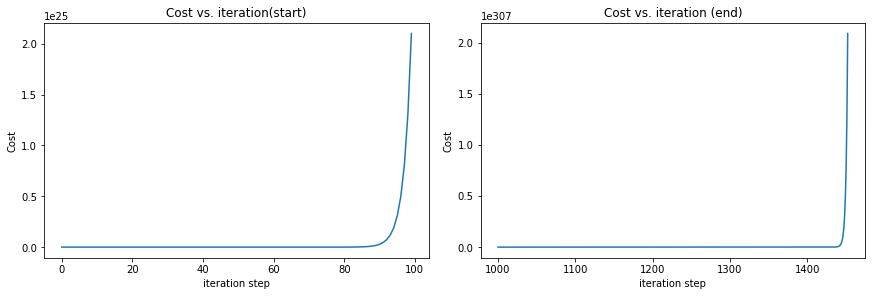

In [60]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(cost_history[:100])
ax2.plot(1000 + np.arange(len(cost_history[1000:])), cost_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()